# 🌿 Olive Yield Across Mediterranean Countries: Environmental and Socioeconomic Factors

## Notebook 03: Exploratory Data Analysis


## Overview

This notebook is the exploratory analysis stage of an end-to-end data project. "01_data_collection_and_consolidation" notebook collected agricultural, environmental, and socioeconomic data from multiple sources, while "02_gold_dataset_engineering" notebook integrated and transformed these data into an analysis-ready Gold dataset.

Using this dataset, the analysis examines olive yield across 11 Mediterranean countries between 2000 and 2024. It explores temporal trends, cross-country differences, yield variability, and associations with selected climate, soil, agricultural, and socioeconomic indicators.

The findings will inform the subsequent business intelligence and predictive modeling stages. Since the analysis uses observational country-level data, the relationships identified are interpreted as associations rather than causal effects.

## Analytical Questions

- How Has Olive Yield Evolved Across Mediterranean Countries Between 2000 and 2024?
- How Has Temperature Changed Relative to the Historical Baseline Across Mediterranean Countries?
- Has the Common Warming Trend Coincided with Declining Olive Yields?
- Are Olive Yields More Strongly Associated with Atmospheric or Soil Conditions?
- Which Countries Combine High Average Olive Yield with Low Relative Variability?
- How Are National Income, Agricultural Dependence, and Olive Yield Variability Related?


## Dataset at a Glance

- Source: Gold dataset created in notebook "02_gold_dataset_engineering"
Unit of analysis: Country-year
- Geographic coverage: 11 Mediterranean olive-producing countries
- Temporal coverage: 2000–2024
- Observations: 274 country-year records
- Feature groups:
    - Agricultural: harvested area, olive production, and olive yield
    - Climate: temperature, precipitation, solar radiation, wind speed, and dew point
    - Soil: soil moisture and soil temperature at multiple depths
    - Socioeconomic: GDP per capita, agriculture’s contribution to GDP, population, and land-use indicators
    - Engineered: previous-year yield, year-over-year yield growth, and annual changes in selected environmental indicators

Details about data collection, sources, integration, validation, and feature engineering are documented in Notebooks 01 and 02.

## Imports and Display Settings

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Static visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Notebook-wide display settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Dataset Loading

The dataset is loaded into a pandas DataFrame for exploratory analysis.

In [3]:
df = pd.read_csv("../data/gold/gold_olive_dataset.csv")
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded: 274 rows and 29 columns


## Dataset Overview
This section evaluates the basic dimensions, structural constraints, temporal range, and geographic scope of the loaded dataset.

In [4]:
expected_records = (
    df["Country"].nunique()
    * (df["Year"].max() - df["Year"].min() + 1)
)

print(
    f"Dataset shape: {df.shape}\n"
    f"Study period: {df['Year'].min()} - {df['Year'].max()}\n"
    f"Countries ({df['Country'].nunique()}): "
    f"{', '.join(sorted(df['Country'].unique()))}\n"
    f"Country-year coverage: {len(df)} of {expected_records} records\n"
    f"Duplicate Country-Year records: "
    f"{df.duplicated(subset=['Country', 'Year']).sum()}"
)

Dataset shape: (274, 29)
Study period: 2000 - 2024
Countries (11): Algeria, Egypt, Greece, Italy, Libya, Morocco, Portugal, Spain, Syria, Tunisia, Turkiye
Country-year coverage: 274 of 275 records
Duplicate Country-Year records: 0


### Interpretation

The dataset contains 274 of the 275 possible country-year records across 11 countries from 2000 to 2024. The absent record is Greece–2024, which was excluded during dataset integration because the corresponding yield and production data were unavailable.

## Data Quality Assessment

Assess dataset completeness by identifying variables and records with missing values.

In [5]:
# Display variables containing missing values
missing_df = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("Missing Values")
    .to_frame()
)

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df

,Missing Values
Previous_Year_Yield,11
Soil_Moisture_Yearly_Change,11
Yield_Growth_Rate,11
Precipitation_Yearly_Change,11
Temperature_Yearly_Change,11
Agriculture_value_added_pct_GDP,4
GDP_per_capita,2


In [6]:
# Examine missing socioeconomic records
df.loc[
    df["Agriculture_value_added_pct_GDP"].isna()
    | df["GDP_per_capita"].isna(),
    [
        "Country",
        "Year",
        "Agriculture_value_added_pct_GDP",
        "GDP_per_capita",
    ],
]

,Country,Year,Agriculture_value_added_pct_GDP,GDP_per_capita
99,Libya,2000,NaN,"7,214.10"
100,Libya,2001,NaN,"6,312.80"
222,Syria,2023,NaN,NaN
223,Syria,2024,NaN,NaN


### Interpretation

The missing values in the lagged and year-over-year features correspond to the first observation for each country. This is expected because these features require a previous year’s value.

The missing socioeconomic values are limited to specific records for Libya and Syria and reflect gaps in the external source data. No values were estimated or interpolated during dataset preparation.

Overall, missingness is limited and does not prevent the exploratory analysis. Calculations involving affected variables will use available observations, while any treatment needed for predictive modeling will be addressed separately.

## 3. Univariate Analysis
### Olive Yield Distribution

Examine the distribution and variability of olive yield across all country-year observations.

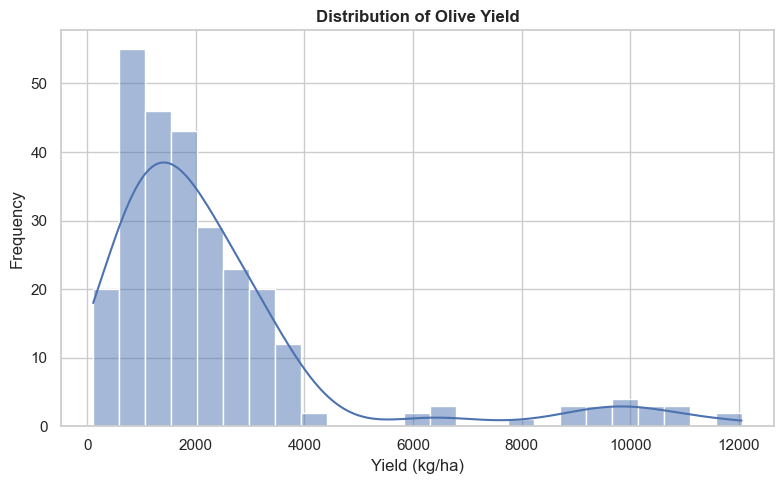

count      274.00
mean     2,397.35
std      2,357.84
min        108.90
25%      1,005.70
50%      1,730.20
75%      2,806.05
max     12,047.90
Name: Yield_kg_per_ha, dtype: float64

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Yield_kg_per_ha"], kde=True, bins=25)

plt.title("Distribution of Olive Yield", fontsize=12, fontweight="bold")
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Display summary statistics
df["Yield_kg_per_ha"].describe()

### Interpretation

- Olive yield is strongly right-skewed, with most observations below 4,000 kg/ha and a small number extending beyond 10,000 kg/ha.  
- These high-yield observations pull the mean above the median.  
- The large standard deviation indicates substantial variation across the dataset. This variation may reflect differences between countries and years, which will be examined in the following sections.  

# 4. Bivariate Analysis

## Temporal Trends: Evolution of Average Olive Yield (2000–2024)

Examine changes in the average olive yield across the 11 countries over time.

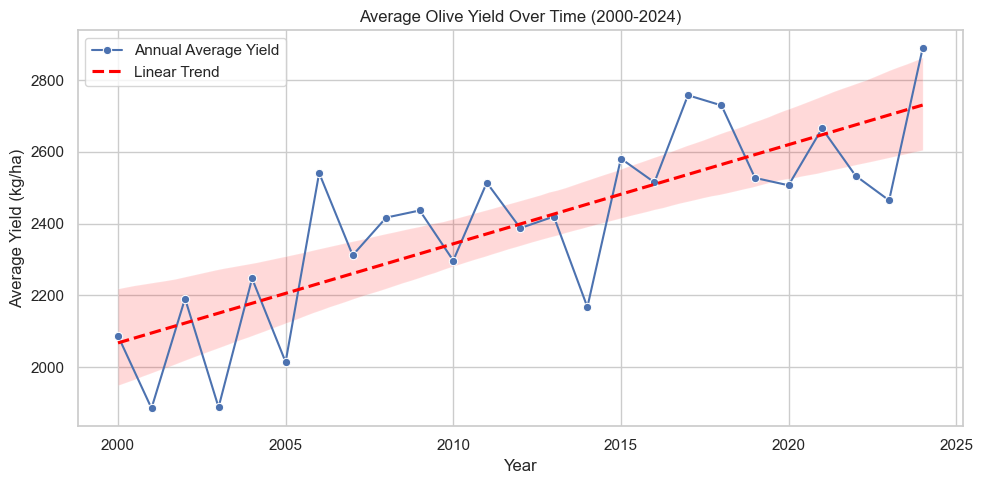

In [8]:
# Compute the annual average yield across countries
yield_trend = (
    df.groupby("Year")["Yield_kg_per_ha"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yield_trend,
    x="Year",
    y="Yield_kg_per_ha",
    marker="o",
    label="Annual Average Yield",
)

sns.regplot(
    data=yield_trend,
    x="Year",
    y="Yield_kg_per_ha",
    scatter=False,
    color="red",
    line_kws={"linestyle": "--"},
    label="Linear Trend",
)

plt.title("Average Olive Yield Over Time (2000-2024)")
plt.xlabel("Year")
plt.ylabel("Average Yield (kg/ha)")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

Average olive yield shows an overall upward trend between 2000 and 2024, despite considerable year-to-year fluctuations. The lowest averages occur mainly during the early 2000s, while 2024 records the highest annual average in the period.

The increase was not consistent from year to year. The regional trend may conceal different country-level trajectories, which are examined in the following section.

## Business Question 1: How Has Olive Yield Evolved Across Mediterranean Countries Between 2000 and 2024?

Examine how olive yield evolved within each country and whether country-level trends followed the regional pattern.

Reading note: Each subplot uses an independent y-axis scale to make country-level changes easier to observe. Absolute yield levels can be compared using the axis values, but the visual magnitude of fluctuations should not be compared directly across panels.

In [9]:
# Create country-level time series
fig = px.line(
    df,
    x="Year",
    y="Yield_kg_per_ha",
    color="Country",
    facet_col="Country",
    facet_col_wrap=3,
    markers=True,
    title="Country-Level Olive Yield Trends (2000-2024)",
    labels={
        "Yield_kg_per_ha": "Yield (kg/ha)",
        "Year": "Year",
    },
)

# Use independent y-axis scales to highlight trends within each country
fig.update_yaxes(matches=None)

# Display y-axis ticks and gridlines in all panels
fig.for_each_yaxis(
    lambda axis: axis.update(
        showticklabels=True,
        showgrid=True,
        ticks="outside",
        gridcolor="lightgray",
    )
)

# Display year labels in all panels
fig.for_each_xaxis(
    lambda axis: axis.update(
        showticklabels=True,
        tickmode="linear",
        dtick=4,
        showgrid=True,
        ticks="outside",
        gridcolor="lightgray",
    )
)

# Remove the "Country=" prefix from facet labels
fig.for_each_annotation(
    lambda annotation: annotation.update(
        text=annotation.text.split("=")[-1],
        font=dict(size=11),
    )
)

# Improve line and marker visibility
fig.update_traces(
    line=dict(width=2),
    marker=dict(size=5),
)

fig.update_layout(
    height=950,
    width=1200,
    showlegend=False,
    hovermode="x unified",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=10),
    title=dict(x=0.5, xanchor="center"),
    margin=dict(t=80, l=60, r=40, b=60),
)

fig.show()

### Interpretation

The country-level analysis shows that the increase in regional average yield was not shared uniformly across all countries.

- Portugal and Algeria show clear long-term increases, despite year-to-year fluctuations.
- Italy and Libya show overall declines from their earlier yield levels.
- Spain, Morocco, Greece, and Syria display substantial annual variation without a consistent long-term direction.
- Egypt maintains distinctly high yield levels throughout the period, despite several fluctuations.
- Tunisia remains at comparatively low yield levels.
- Türkiye is relatively stable for much of the period, followed by a sharp increase in the final years.

Overall, the regional average masks distinct country-level trajectories, supporting the use of country-level analysis throughout the notebook.

## Business Question 2: How Has Temperature Changed Relative to the Historical Baseline Across Mediterranean Countries?

This analysis examines annual temperature change relative to the 1951–1980 baseline across countries and years. Positive values indicate temperatures above the historical baseline, with warmer colors representing larger departures. The heatmap provides climatic context for interpreting the olive yield patterns identified earlier.

In [10]:
# Create the country-year temperature change matrix
temp_matrix = df.pivot_table(
    index="Country",
    columns="Year",
    values="Temperature_change",
    aggfunc="mean",
)

# Plot the heatmap
fig = px.imshow(
    temp_matrix,
    aspect="auto",
    color_continuous_scale="RdYlBu_r",
    title=(
        "Temperature Change Relative to the 1951-1980 Baseline "
        "Across Mediterranean Countries (2000-2024)"
    ),
    labels={
        "x": "Year",
        "y": "Country",
        "color": "Change from Baseline (°C)",
    },
)

fig.update_layout(
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        x=0.5,
        xanchor="center",
    ),
    coloraxis_colorbar=dict(
        title="°C",
    ),
)

fig.update_xaxes(
    tickmode="linear",
    dtick=2,
)

fig.show()

### Interpretation

Temperatures remain above the 1951–1980 baseline across most country-year observations, with departures generally becoming more pronounced after 2015.

Elevated values occur across several countries simultaneously, particularly in 2010, 2018, and 2022–2024. The strongest and most widespread departures appear during the early 2020s, indicating a shared Mediterranean warming pattern rather than isolated country-level changes.

Data note: Greece–2024 is absent from the Gold dataset because the corresponding yield and production record was unavailable during integration. The blank cell reflects this panel-coverage gap, not a missing temperature observation in the original climate source.

## Business Question 3: Has the Common Warming Trend Coincided with Declining Olive Yields?

The previous analysis showed increasing temperatures relative to the 1951–1980 baseline across most Mediterranean countries. This analysis compares the evolution of temperature change and olive yield within each country to assess whether the common warming trend coincided with declining yield between 2000 and 2024.

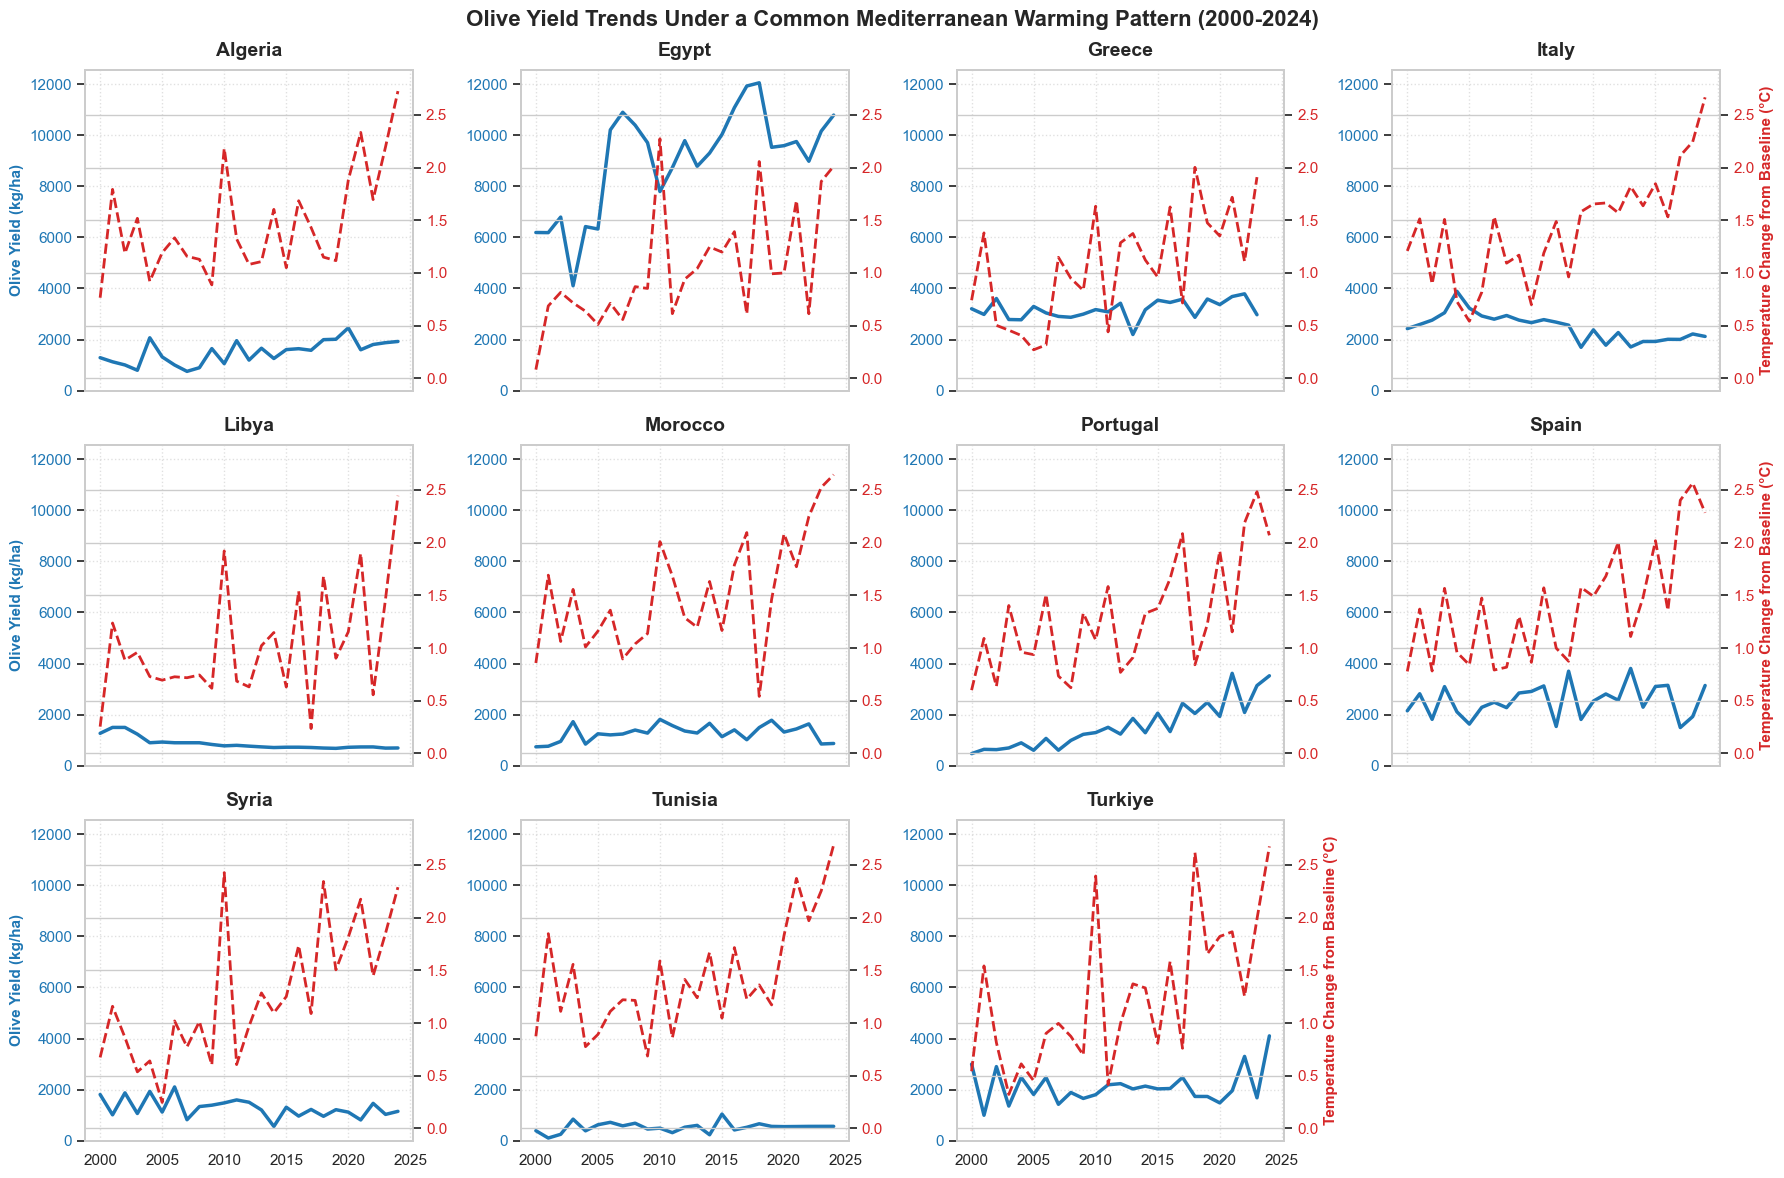

In [11]:
# Sort observations chronologically by country and year
df_plot = df.sort_values(["Country", "Year"])
countries = sorted(df_plot["Country"].unique())

# Apply common axis limits across all country panels
yield_min = 0
yield_max = df_plot["Yield_kg_per_ha"].max() + 500

temp_min = df_plot["Temperature_change"].min() - 0.2
temp_max = df_plot["Temperature_change"].max() + 0.2

# Create country-level comparison panels
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 12),
    sharex=True,
)

axes = axes.flatten()

for i, country in enumerate(countries):
    ax1 = axes[i]
    country_data = df_plot[df_plot["Country"] == country]

    # Left axis: olive yield
    yield_color = "#1f77b4"

    ax1.plot(
        country_data["Year"],
        country_data["Yield_kg_per_ha"],
        color=yield_color,
        linewidth=2.5,
    )

    ax1.set_title(
        country,
        fontsize=14,
        fontweight="bold",
        pad=10,
    )

    ax1.set_ylim(yield_min, yield_max)
    ax1.tick_params(axis="y", labelcolor=yield_color)
    ax1.grid(True, linestyle=":", alpha=0.6)

    if i in (0, 4, 8):
        ax1.set_ylabel(
            "Olive Yield (kg/ha)",
            color=yield_color,
            fontsize=11,
            fontweight="bold",
        )

    # Right axis: temperature change relative to the historical baseline
    ax2 = ax1.twinx()
    temperature_color = "#d62728"

    ax2.plot(
        country_data["Year"],
        country_data["Temperature_change"],
        color=temperature_color,
        linestyle="--",
        linewidth=2,
    )

    ax2.set_ylim(temp_min, temp_max)
    ax2.tick_params(axis="y", labelcolor=temperature_color)

    if i in (3, 7, 10):
        ax2.set_ylabel(
            "Temperature Change from Baseline (°C)",
            color=temperature_color,
            fontsize=11,
            fontweight="bold",
        )

# Remove the unused subplot
fig.delaxes(axes[-1])

fig.suptitle(
    "Olive Yield Trends Under a Common Mediterranean "
    "Warming Pattern (2000-2024)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

## Interpretation

Olive yield does not show a uniform response despite the broadly shared warming trend above the 1951–1980 baseline. 

- Egypt, Portugal, and Algeria show overall yield increases alongside the warming trend.  
- Italy, Libya, and Syria show generally declining yield trajectories.  
- Greece, Spain, Morocco, Tunisia, and Türkiye show fluctuating yields without a consistent response matching the temperature series.   

Overall, the common warming pattern coincides with different yield outcomes across countries. The figure does not establish that temperature caused these changes, but the contrasting trajectories motivate a broader country-level analysis of environmental associations.

Data note: The Greece series ends in 2023 because Greece–2024 is absent from the Gold dataset.

## Business Question 4: Are Olive Yields More Strongly Associated with Atmospheric or Soil Conditions?

This analysis calculates country-level Pearson correlations between olive yield and selected atmospheric and soil indicators from 2000 to 2024. The comparison helps identify the strongest environmental associations and whether those patterns differ across countries.

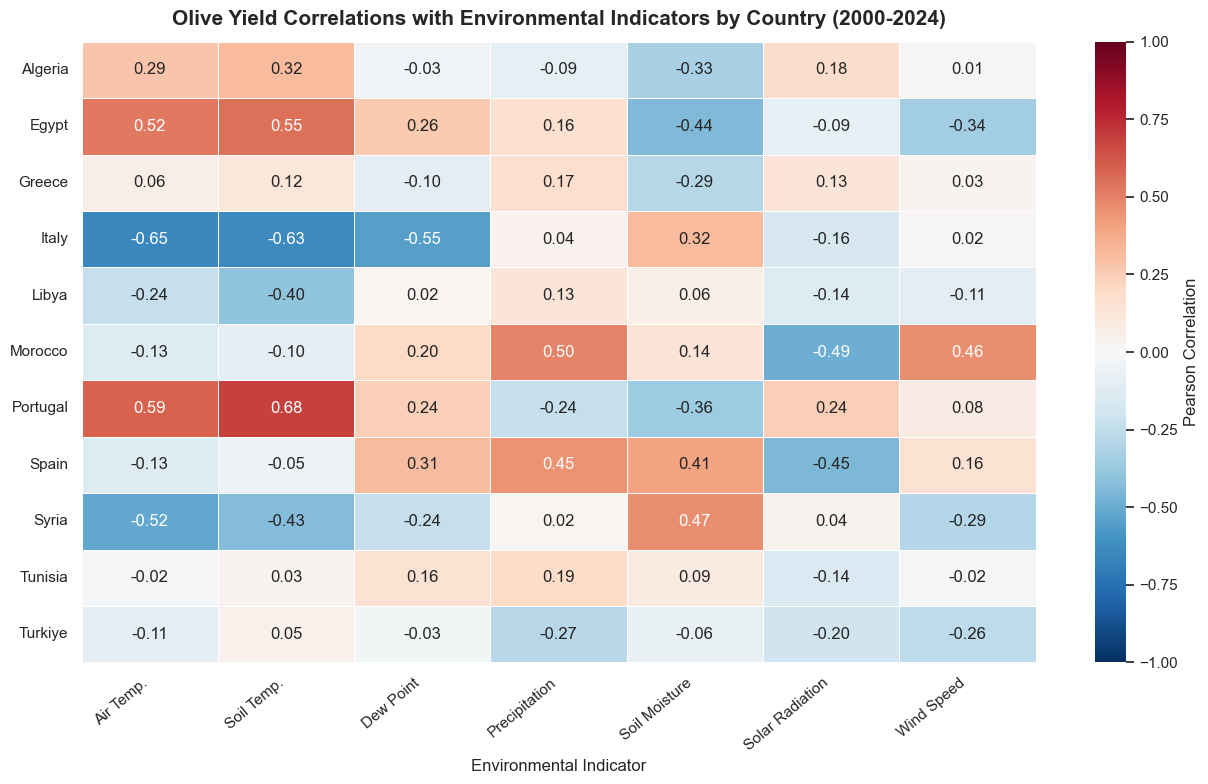

In [14]:
# Environmental variables
core_vars = [
    "Mean_Temperature_C",
    "Weighted_Average_Soil_Temperature_7_100cm",
    "Mean_Dewpoint_C",
    "Total_Precipitation_mm",
    "Weighted_Average_Soil_Moisture_0_100cm",
    "Total_Solar_Radiation_MJ_m2",
    "Mean_Wind_Speed_m_s",
    
]

target = "Yield_kg_per_ha"

# Compute country-level Pearson correlations
corr_data = []

for country in sorted(df["Country"].unique()):
    country_df = df[df["Country"] == country]

    row = {"Country": country}

    for var in core_vars:
        row[var] = country_df[target].corr(country_df[var])

    corr_data.append(row)

corr_df = pd.DataFrame(corr_data).set_index("Country")

# Cleaner variable names for display
corr_df.columns = [
    "Air Temp.",
    "Soil Temp.",
    "Dew Point",
    "Precipitation",
    "Soil Moisture",
    "Solar Radiation",
    "Wind Speed",
]

# Plot the correlation matrix
plt.figure(figsize=(13, 8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"},
)

plt.title(
    "Olive Yield Correlations with Environmental Indicators by Country (2000-2024)",
    fontsize=15,
    weight="bold",
    pad=12,
)

plt.xlabel("Environmental Indicator", fontsize=12)
plt.ylabel("")

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


### Interpretation

The heatmap reveals substantial differences in yield–environment associations across countries.
Environmental associations with olive yield vary considerably across countries.

- Temperature indicators show strong negative correlations in Italy and Syria but strong positive correlations in Portugal and Egypt.  
- Precipitation and soil moisture are more prominent in Morocco, Spain, and Syria, although soil moisture is negatively correlated with yield in Egypt.  
- Dew point, solar radiation, and wind speed generally show weaker or less consistent patterns, with notable country-specific exceptions.

Overall, neither atmospheric nor soil conditions consistently show stronger associations across the full sample. No single environmental indicator provides a common explanation for olive yield variation across all countries.

These correlations measure linear associations and should not be interpreted as causal effects.

## Business Question 5: Which Countries Combine High Average Olive Yield with Low Relative Variability?

The previous analysis measured variability in annual yield growth within a macroeconomic comparison. This analysis instead compares each country’s average olive yield with its coefficient of variation (CV) between 2000 and 2024. The CV measures historical yield variation relative to average yield, allowing countries with different yield levels to be compared on a common scale.

Reading note: Countries positioned higher have greater average yield, while countries further left have lower historical relative variability.

In [15]:
# Aggregate country-level yield statistics
df_bench = (
    df.groupby("Country", as_index=False)
    .agg(
        Yield_Mean=("Yield_kg_per_ha", "mean"),
        Yield_Std=("Yield_kg_per_ha", "std"),
    )
)

# Calculate the coefficient of variation
df_bench["Relative_Variability_Pct"] = (
    df_bench["Yield_Std"] / df_bench["Yield_Mean"]
) * 100

# Create the benchmarking chart
fig = px.scatter(
    df_bench,
    x="Relative_Variability_Pct",
    y="Yield_Mean",
    color="Country",
    text="Country",
    hover_data={
        "Yield_Mean": ":.0f",
        "Relative_Variability_Pct": ":.1f",
    },
    title="Average Olive Yield and Relative Variability by Country (2000-2024)",
    labels={
        "Relative_Variability_Pct": "Relative Yield Variability (CV %)",
        "Yield_Mean": "Average Yield (kg/ha)",
    },
    color_discrete_sequence=px.colors.qualitative.Dark24,
)

fig.update_traces(
    marker=dict(size=11),
    textposition="top center",
)

fig.update_layout(
    height=650,
    width=1050,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=90, l=70, r=40, b=60),
    font=dict(size=11),
    title=dict(x=0.5, xanchor="center"),
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray",
    ticksuffix="%",
    zeroline=False,
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    tickformat=",",
    zeroline=False,
)

fig.show()

### Interpretation

The benchmark reveals distinct country profiles in terms of average yield and relative variability.

- Egypt stands apart with the highest average yield, approximately 9,000 kg/ha, and moderate relative variability of around 22%.  
- Greece combines the lowest coefficient of variation, approximately 13%, with the second-highest average yield, representing the strongest balance between high yield and low historical variability.  
- Italy and Spain record similar average yields, although Italy shows slightly lower relative variability.  
- Portugal has the highest coefficient of variation, approximately 58%, despite having a moderate average yield.  
- Tunisia combines the lowest average yield with comparatively high relative variability. Most remaining countries are concentrated at lower yield levels and CV values of approximately 25%–37%.

Overall, high average yield does not necessarily coincide with high relative variability. Portugal’s high CV may also partly reflect its substantial long-term yield increase, since this measure captures variation in yield levels across the full study period.

## Business Question 6: How Are National Income, Agricultural Dependence, and Olive Yield Variability Related?

This analysis compares each country’s average GDP per capita, agriculture’s contribution to GDP, and olive yield variability between 2000 and 2024. Yield variability is measured as the standard deviation of annual yield growth rates.

In [16]:
# Aggregate country-level indicators and sort by GDP per capita
df_macro = (
    df.groupby("Country", as_index=False)
    .agg(
        GDP_per_capita=("GDP_per_capita", "mean"),
        Agri_GDP_Pct=("Agriculture_value_added_pct_GDP", "mean"),
        Yield_Volatility=("Yield_Growth_Rate", "std"),
    )
    .sort_values("GDP_per_capita")
)

countries = df_macro["Country"]

# Create the comparison chart
fig = make_subplots(
    rows=1,
    cols=3,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    subplot_titles=(
        "GDP per Capita",
        "Agricultural Dependence",
        "Yield Variability",
    ),
)

# GDP per capita
fig.add_trace(
    go.Bar(
        x=df_macro["GDP_per_capita"],
        y=countries,
        orientation="h",
        marker_color="#4363D8",
        opacity=0.9,
    ),
    row=1,
    col=1,
)

# Agriculture's contribution to GDP
fig.add_trace(
    go.Bar(
        x=df_macro["Agri_GDP_Pct"],
        y=countries,
        orientation="h",
        marker_color="#3CB44B",
        opacity=0.9,
    ),
    row=1,
    col=2,
)

# Yield variability
fig.add_trace(
    go.Bar(
        x=df_macro["Yield_Volatility"],
        y=countries,
        orientation="h",
        marker_color="#E6194B",
        opacity=0.9,
    ),
    row=1,
    col=3,
)

fig.update_layout(
    title={
        "text": (
            "National Income, Agricultural Dependence, "
            "and Olive Yield Variability (2000-2024)"
        ),
        "x": 0.5,
        "xanchor": "center",
    },
    height=650,
    width=1200,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=140, r=40, t=90, b=50),
    font=dict(
        family="Arial",
        size=12,
        color="#2F3E5C",
    ),
)

fig.update_xaxes(
    tickformat="$,",
    showgrid=True,
    gridcolor="whitesmoke",
    zeroline=False,
    row=1,
    col=1,
)

fig.update_xaxes(
    ticksuffix="%",
    showgrid=True,
    gridcolor="whitesmoke",
    zeroline=False,
    row=1,
    col=2,
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="whitesmoke",
    zeroline=False,
    row=1,
    col=3,
)

fig.update_yaxes(
    showgrid=False,
    linecolor="lightgray",
    tickfont=dict(
        size=13,
        color="#1F2937",
    ),
)

for annotation in fig.layout.annotations:
    annotation.font.size = 15
    annotation.font.color = "#2F3E5C"

fig.show()

### Interpretation

Higher-income countries generally derive a smaller share of GDP from agriculture, while lower-income countries tend to rely more heavily on the agricultural sector.

Annual yield-growth variability does not follow the same pattern. Tunisia and Türkiye record the highest variability, while Libya records the lowest. Countries with similar income levels or agricultural dependence can therefore experience substantially different year-to-year yield changes.

This result complements BQ5 by measuring a different aspect of stability: the coefficient of variation compares yield levels with each country’s historical average, whereas yield-growth variability measures the irregularity of annual changes.

Overall, lower income generally coincides with greater agricultural dependence, but not consistently with greater yield-growth variability. Economic context alone does not account for differences in country-level yield stability.

# Executive Summary

This exploratory analysis examined olive yield across 11 Mediterranean countries between 2000 and 2024 using agricultural, climate, soil, and socioeconomic indicators. The results reveal substantial differences in yield levels, historical variability, and environmental relationships across countries.

Average olive yield shows an overall regional increase, but this pattern is not shared uniformly. Egypt consistently records the highest yields, while Portugal and Algeria show clear long-term increases. Italy and Libya decline relative to their earlier yield levels, and several other countries are characterized primarily by annual fluctuations.

Temperatures moved increasingly above the 1951–1980 baseline during the study period, particularly after 2015. However, this common warming trend did not coincide with a uniform decline in olive yield. Some countries recorded declining yields as temperatures increased, while others maintained or increased their yields.

Environmental associations are strongly country-specific. Temperature-related indicators show positive correlations with yield in Portugal and Egypt but negative correlations in Italy and Syria. Precipitation and soil moisture are more prominent in Morocco, Spain, and Syria. Overall, no atmospheric or soil indicator shows a consistent relationship with yield across all countries.

The yield benchmarking analysis shows that high average yield does not necessarily coincide with high relative variability. Egypt combines the highest average yield with moderate variation, while Greece combines comparatively high yield with the lowest coefficient of variation. Portugal records the highest variation relative to its historical average, partly reflecting its substantial long-term increase.

The socioeconomic comparison indicates that higher-income countries generally derive a smaller share of GDP from agriculture, while lower-income countries tend to be more agriculturally dependent. However, variability in annual yield growth does not follow the same pattern. Countries with similar income levels or agricultural dependence can experience substantially different levels of year-to-year yield variation.

Overall, Mediterranean olive yield cannot be represented by a single regional pattern. Yield trajectories, historical variability, and environmental associations differ considerably across countries. These findings support the use of country-level context and features in the subsequent business intelligence and predictive modeling stages.